# Fase 1 — Análisis Exploratorio (EDA)
### Music Data Analysis (Spotify) · Omar Mora Flores

**Pregunta central:** ¿Qué características de audio se asocian con mayor popularidad?

Dataset de **114,000 pistas** de Spotify con 114 géneros y features de audio (danceability,
energy, valence, etc.). La variable de interés es `popularity` (0–100).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "data" / "dataset.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"; REPORTS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":130,"axes.titleweight":"bold"})

AUDIO = ["danceability","energy","valence","tempo","acousticness",
         "speechiness","instrumentalness","loudness","liveness"]
df = pd.read_csv(ROOT/"data"/"dataset.csv")
print("Shape:", df.shape)

Shape: (114000, 21)


## 1.1 Carga y descripción

In [2]:
print("Géneros:", df.track_genre.nunique(), "| artistas únicos:", df.artists.nunique())
print("track_id duplicados (misma canción en varios géneros):", int(df.duplicated('track_id').sum()))
print("Nulos:", {k:int(v) for k,v in df.isnull().sum().items() if v>0})

# Deduplicar por track_id para análisis a nivel canción (mantenemos los duplicados de género
# para la Fase 2). Eliminamos columna índice y 1 fila con nulos de texto.
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")
songs = df.dropna(subset=["track_name","artists"]).drop_duplicates("track_id").reset_index(drop=True)
print("\nCanciones únicas para EDA:", songs.shape)
songs[["popularity"]+AUDIO].describe().round(2).T

Géneros: 114 | artistas únicos: 31437
track_id duplicados (misma canción en varios géneros): 24259
Nulos: {'artists': 1, 'album_name': 1, 'track_name': 1}

Canciones únicas para EDA: (89740, 20)


,count,mean,std,min,25%,50%,75%,max
popularity,89740.0,33.20,20.58,0.00,19.00,33.00,49.00,100.00
danceability,89740.0,0.56,0.18,0.00,0.45,0.58,0.69,0.98
energy,89740.0,0.63,0.26,0.00,0.46,0.68,0.85,1.00
valence,89740.0,0.47,0.26,0.00,0.25,0.46,0.68,1.00
tempo,89740.0,122.06,30.12,0.00,99.26,122.01,140.08,243.37
acousticness,89740.0,0.33,0.34,0.00,0.02,0.19,0.62,1.00
speechiness,89740.0,0.09,0.11,0.00,0.04,0.05,0.09,0.96
instrumentalness,89740.0,0.17,0.32,0.00,0.00,0.00,0.10,1.00
loudness,89740.0,-8.50,5.22,-49.53,-10.32,-7.18,-5.11,4.53
liveness,89740.0,0.22,0.19,0.00,0.10,0.13,0.28,1.00


## 1.2 Distribución de popularidad

Popularidad media: 33.2 | % con popularity>70: 3.0%


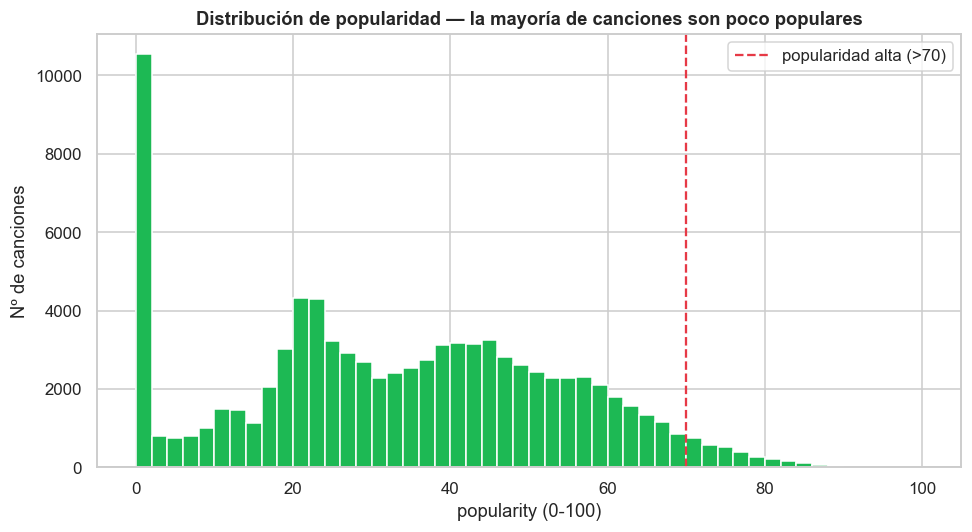

In [3]:
pop_hi = (songs.popularity > 70).mean()*100
print(f"Popularidad media: {songs.popularity.mean():.1f} | % con popularity>70: {pop_hi:.1f}%")
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(songs.popularity, bins=50, color="#1DB954", edgecolor="white")
ax.axvline(70, ls="--", color="#E63946", label="popularidad alta (>70)")
ax.set_title("Distribución de popularidad — la mayoría de canciones son poco populares")
ax.set_xlabel("popularity (0-100)"); ax.set_ylabel("Nº de canciones"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS/"01_popularity_distribution.png", bbox_inches="tight"); plt.show()

## 1.3 Correlación de features de audio con la popularidad

Correlación con popularity:
 instrumentalness   -0.127
loudness            0.072
danceability        0.064
speechiness        -0.047
acousticness       -0.039
duration_ms        -0.023
liveness           -0.014
energy              0.014
valence            -0.012
tempo               0.007


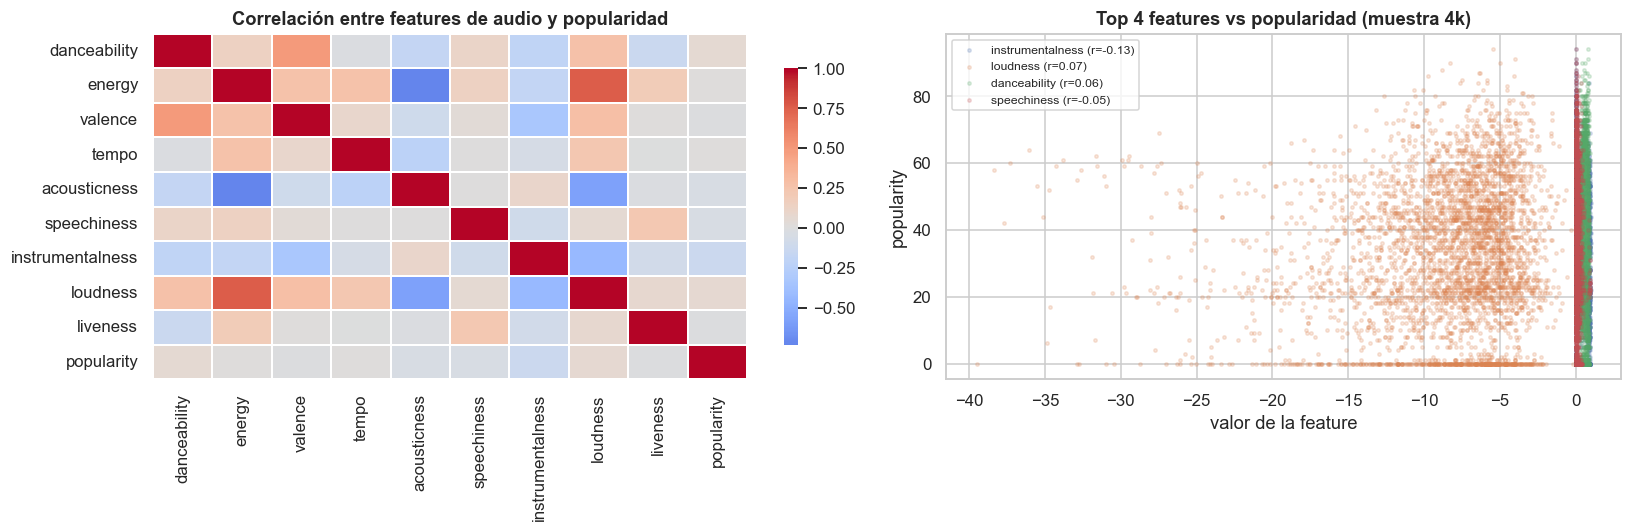

In [4]:
corr = songs[AUDIO+["popularity","duration_ms"]].corr()
cpop = corr["popularity"].drop("popularity").sort_values(key=lambda s:s.abs(), ascending=False)
print("Correlación con popularity:\n", cpop.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15,5), gridspec_kw={"width_ratios":[1.1,1]})
sns.heatmap(songs[AUDIO+["popularity"]].corr(), cmap="coolwarm", center=0, ax=axes[0],
            annot=False, linewidths=.3, cbar_kws={"shrink":.8})
axes[0].set_title("Correlación entre features de audio y popularidad")
top4 = cpop.head(4).index
m = songs.sample(4000, random_state=42)
for c in top4:
    axes[1].scatter(m[c], m["popularity"], s=5, alpha=.2, label=f"{c} (r={cpop[c]:.2f})")
axes[1].set_title("Top 4 features vs popularidad (muestra 4k)")
axes[1].set_xlabel("valor de la feature"); axes[1].set_ylabel("popularity"); axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS/"02_audio_features_correlation.png", bbox_inches="tight"); plt.show()

**Hallazgo clave:** todas las correlaciones audio↔popularidad son **muy débiles** (|r| < 0.1).
Las features de audio **no explican** la popularidad por sí solas — esta depende de factores
externos (marketing, artista, viralidad). Es un resultado válido e importante a documentar.

## 1.4 Top canciones y artistas

Top 10 canciones:
                            track_name                    artists  popularity track_genre
            Unholy (feat. Kim Petras)       Sam Smith;Kim Petras         100       dance
Quevedo: Bzrp Music Sessions, Vol. 52           Bizarrap;Quevedo          99     hip-hop
                      I'm Good (Blue)    David Guetta;Bebe Rexha          98       dance
                           La Bachata              Manuel Turizo          98       latin
                      Me Porto Bonito Bad Bunny;Chencho Corleone          97       latin
                     Tití Me Preguntó                  Bad Bunny          97       latin
                  Under The Influence                Chris Brown          96       dance
                               Efecto                  Bad Bunny          96       latin
                      I Ain't Worried                OneRepublic          96       piano
                        Ojitos Lindos    Bad Bunny;Bomba Estéreo          95       latin


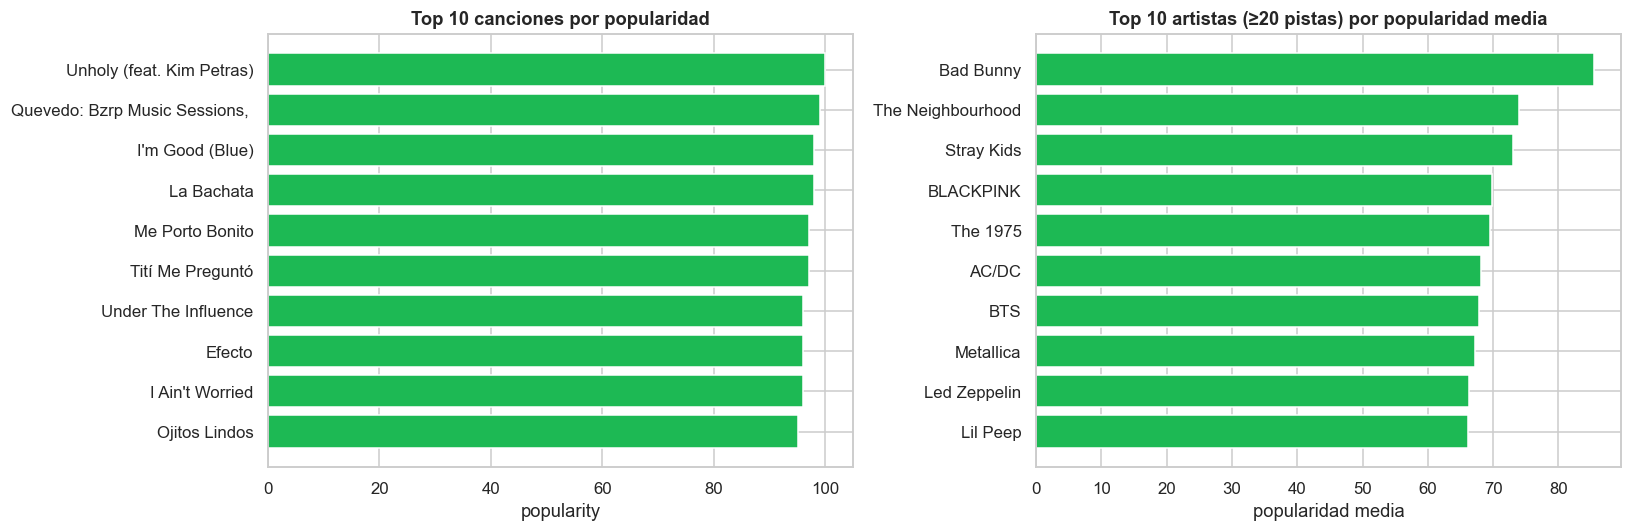

In [5]:
top_songs = songs.nlargest(10, "popularity")[["track_name","artists","popularity","track_genre"]]
art = (songs.groupby("artists").agg(pop=("popularity","mean"), n=("track_id","size")))
top_art = art[art.n>=20].nlargest(10, "pop")
print("Top 10 canciones:\n", top_songs.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15,5))
axes[0].barh(top_songs["track_name"].str.slice(0,30)[::-1], top_songs["popularity"][::-1], color="#1DB954")
axes[0].set_title("Top 10 canciones por popularidad"); axes[0].set_xlabel("popularity")
axes[1].barh(top_art.index.str.slice(0,28)[::-1], top_art["pop"][::-1], color="#1DB954")
axes[1].set_title("Top 10 artistas (≥20 pistas) por popularidad media"); axes[1].set_xlabel("popularidad media")
fig.tight_layout(); fig.savefig(REPORTS/"03_top_tracks_artists.png", bbox_inches="tight"); plt.show()

## 1.5 Canciones muy populares vs. poco populares

                  Populares (>70)  Poco populares (<30)
danceability                0.625                 0.547
energy                      0.666                 0.636
valence                     0.512                 0.468
acousticness                0.228                 0.337
speechiness                 0.081                 0.099
instrumentalness            0.032                 0.220


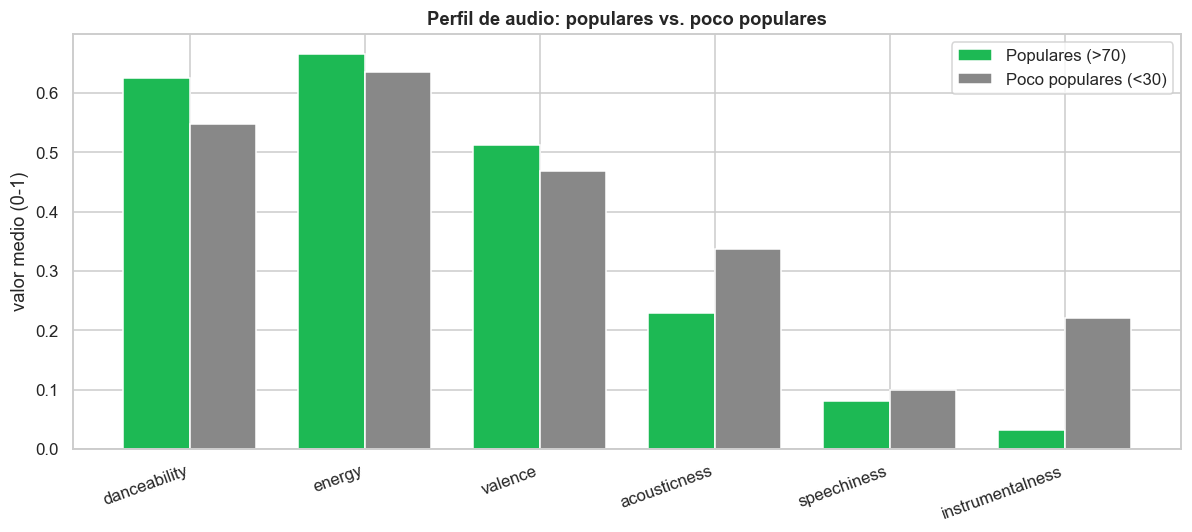

In [6]:
feats01 = ["danceability","energy","valence","acousticness","speechiness","instrumentalness"]
hi = songs[songs.popularity>70][feats01].mean()
lo = songs[songs.popularity<30][feats01].mean()
comp = pd.DataFrame({"Populares (>70)":hi, "Poco populares (<30)":lo})
print(comp.round(3).to_string())

x = np.arange(len(feats01)); w=0.38
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(x-w/2, hi.values, w, label="Populares (>70)", color="#1DB954")
ax.bar(x+w/2, lo.values, w, label="Poco populares (<30)", color="#888")
ax.set_xticks(x); ax.set_xticklabels(feats01, rotation=20, ha="right")
ax.set_title("Perfil de audio: populares vs. poco populares"); ax.set_ylabel("valor medio (0-1)"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS/"04_popular_vs_unpopular.png", bbox_inches="tight"); plt.show()

## 1.6 Conclusiones del EDA

1. **La popularidad está sesgada a valores bajos** (media 33, solo ~4% supera 70).
2. **Las features de audio no predicen la popularidad** (|r| < 0.1) → hallazgo central: la
 popularidad depende de factores fuera del audio.
3. Las canciones populares son ligeramente **más bailables y enérgicas** y **menos acústicas/
 instrumentales**, pero la diferencia es modesta.
4. Hay **24,259 duplicados por `track_id`** (misma canción en varios géneros) — se deduplican a
 nivel canción aquí y se conservan para el análisis por género (Fase 2).

 **Siguiente:** `02_genre_analysis.ipynb` (perfiles de audio por género) y luego clustering.